In [21]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Train.csv to Train.csv


In [3]:
df = pd.read_csv("Train.csv")

In [4]:
print("Dataset Shape:",df.shape)
df.head()

Dataset Shape: (10999, 12)


,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


In [5]:
print(df.isnull().sum())

ID                     0
Warehouse_block        0
Mode_of_Shipment       0
Customer_care_calls    0
Customer_rating        0
Cost_of_the_Product    0
Prior_purchases        0
Product_importance     0
Gender                 0
Discount_offered       0
Weight_in_gms          0
Reached.on.Time_Y.N    0
dtype: int64


In [6]:
X = df.drop("Reached.on.Time_Y.N",axis=1)
y = df["Reached.on.Time_Y.N"]

In [7]:
X_encoded = X.copy()
cat_cols = X_encoded.select_dtypes(include='object').columns
for col in cat_cols:
    X_encoded[col] = LabelEncoder().fit_transform(X_encoded[col])
X_encoded.head()

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms
0,1,3,0,4,2,177,3,1,0,44,1233
1,2,4,0,4,5,216,2,1,1,59,3088
2,3,0,0,2,2,183,4,1,1,48,3374
3,4,1,0,3,3,176,4,2,1,10,1177
4,5,2,0,2,2,184,3,2,0,46,2484


In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

In [9]:
X_train,X_test,y_train,y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.25,
    random_state=42
)

In [10]:
log_model = LogisticRegression()
log_model.fit(X_train,y_train)
log_pred = log_model.predict(X_test)

In [12]:
print("Logistic Regression Results")
print("Accuracy:",
      accuracy_score(y_test,log_pred))

print("Precision:",
      precision_score(y_test,log_pred))

print("Recall:",
      recall_score(y_test,log_pred))

Logistic Regression Results
Accuracy: 0.6556363636363637
Precision: 0.7246006389776358
Recall: 0.6872727272727273


In [11]:
rf_model = RandomForestClassifier(
    n_estimators=60,
    random_state=42
)
rf_model.fit(X_train,y_train)
rf_pred = rf_model.predict(X_test)

In [13]:
print("Random Forest Results")
print("Accuracy:",
      accuracy_score(y_test,rf_pred))

print("Precision:",
      precision_score(y_test,rf_pred))

print("Recall:",
      recall_score(y_test,rf_pred))

Random Forest Results
Accuracy: 0.672
Precision: 0.7894736842105263
Recall: 0.6181818181818182


In [14]:
results = pd.DataFrame({
    "Model":["Logistic","RandomForest"],

    "Accuracy":[
        accuracy_score(y_test,log_pred),
        accuracy_score(y_test,rf_pred)
    ],

    "Precision":[
        precision_score(y_test,log_pred),
        precision_score(y_test,rf_pred)
    ],

    "Recall":[
        recall_score(y_test,log_pred),
        recall_score(y_test,rf_pred)
    ]
})
results

,Model,Accuracy,Precision,Recall
0,Logistic,0.655636,0.724601,0.687273
1,RandomForest,0.672000,0.789474,0.618182


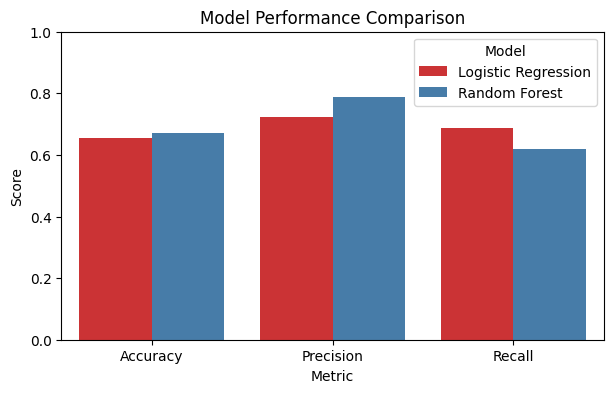

In [22]:
models = ['Logistic Regression','Random Forest']

accuracy = [
    accuracy_score(y_test,log_pred),
    accuracy_score(y_test,rf_pred)
]
precision = [
    precision_score(y_test,log_pred),
    precision_score(y_test,rf_pred)
]
recall = [
    recall_score(y_test,log_pred),
    recall_score(y_test,rf_pred)
]
results = pd.DataFrame({
    'Model':models,
    'Accuracy':accuracy,
    'Precision':precision,
    'Recall':recall
})

results_melt = results.melt(
    id_vars='Model',
    var_name='Metric',
    value_name='Score'
)

plt.figure(figsize=(7,4))

sns.barplot(
    data=results_melt,
    x='Metric',
    y='Score',
    hue='Model',
    palette='Set1'
)
plt.ylim(0,1)
plt.title("Model Performance Comparison")
plt.show()